#**Smart Digital Twin System for Personal Productivity Prediction**

Notebook ini menggunakan model Multi-Output LSTM untuk menganalisis aktivitas pengguna dan menghasilkan dua jenis prediksi sekaligus, yaitu:

 - Prediksi skor produktivitas
 - Prediksi kategori kondisi pengguna:
   1. At Risk
   2. Steady
   3. Thriving

Model dibuat menggunakan pendekatan Deep Learning berbasis data time series untuk memahami pola aktivitas harian pengguna selama beberapa hari terakhir.

**Roadmap Proyek**

 - Eksplorasi dan Pemahaman Data Dasar (EDA)
 - Analisis Karakteristik Time Series
 - Feature Engineering dan Pelabelan Data
 - Preprocessing Data (Anti Data Leakage)
 - Perancangan Model Multi-Output LSTM
 - Pelatihan Model dan Monitoring
 - Evaluasi Kinerja Model
 - Simulasi Prediksi

##**1. Library**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
import tensorflow as tf
import datetime

from tensorflow.keras import layers
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

##**2. Eksplorasi & Pemahaman Data Dasar (EDA)**

Tahap awal untuk memahami struktur dataset, tipe data, serta kondisi data sebelum diproses lebih lanjut.

###**2.1 Memasukkan dan Memeriksa Data Awal**

**Pada tahap ini dilakukan:**
- membaca dataset,
- melihat ukuran data,
- mengecek tipe data,
- menampilkan beberapa data awal.

In [ ]:
#baca dataset
df = pd.read_csv('datasetdailylogs.csv')
print("Dimensi Dataset:", df.shape)
print("\nInformasi Kolom & Tipe Data:")
df.info()

Dimensi Dataset: (73100, 18)

Informasi Kolom & Tipe Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   date                        73100 non-null  object 
 1   user_id                     73100 non-null  int64  
 2   sleep_duration              73100 non-null  float64
 3   sleep_quality               73100 non-null  int64  
 4   study_work_duration         73100 non-null  float64
 5   break_duration              73100 non-null  float64
 6   physical_activity_duration  73100 non-null  float64
 7   screen_time_duration        73100 non-null  float64
 8   stress_level                73100 non-null  int64  
 9   mood_score                  73100 non-null  int64  
 10  focus_score                 73100 non-null  int64  
 11  task_planned                73100 non-null  int64  
 12  task_completed              7

In [ ]:
print("\n5 Data Teratas:")
df.head()


5 Data Teratas:


,date,user_id,sleep_duration,sleep_quality,study_work_duration,break_duration,physical_activity_duration,screen_time_duration,stress_level,mood_score,focus_score,task_planned,task_completed,task_completion_rate,productivity_score,day_of_week,month,is_weekend
0,1/1/2024,1,7.14,6,6.99,0.0,33.0,8.41,4,3,7,9,4,0.444,53.76,0,1,0
1,1/2/2024,1,7.61,5,8.42,0.0,57.0,8.21,6,5,2,6,2,0.333,35.32,1,1,0
2,1/3/2024,1,8.00,7,7.21,2.6,29.0,5.70,3,6,7,7,5,0.714,72.06,2,1,0
3,1/4/2024,1,7.19,5,7.85,0.2,51.0,7.13,5,4,6,9,5,0.556,55.74,3,1,0
4,1/5/2024,1,7.95,8,7.17,2.7,51.0,5.29,3,8,5,5,4,0.800,73.50,4,1,0


###**2.2 Statistik Deskriptif**

Menampilkan ringkasan statistik dari setiap fitur numerik seperti:
- rata-rata,
- nilai minimum,
- nilai maksimum,
- dan standar deviasi.

In [ ]:
print("Ringkasan Statistik Deskriptif:")
df.describe()

Ringkasan Statistik Deskriptif:


,user_id,sleep_duration,sleep_quality,study_work_duration,break_duration,physical_activity_duration,screen_time_duration,stress_level,mood_score,focus_score,task_planned,task_completed,task_completion_rate,productivity_score,day_of_week,month,is_weekend
count,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,50.500000,7.216745,6.190287,6.529603,2.445585,27.449843,6.518878,4.224897,6.161149,5.673789,6.012202,3.513543,0.585409,61.422665,2.991792,6.519836,0.284542
std,28.866267,0.888991,1.456798,3.188538,2.443633,19.172897,1.686280,1.176852,1.465256,1.659702,2.001713,1.409182,0.131683,11.464014,2.000681,3.449574,0.451199
min,1.000000,4.795000,1.000000,0.000000,0.000000,0.000000,1.915000,1.000000,1.000000,1.000000,3.000000,0.000000,0.000000,17.180000,0.000000,1.000000,0.000000
25%,25.750000,6.610000,5.000000,2.780000,0.000000,12.000000,5.380000,3.000000,5.000000,5.000000,4.000000,2.000000,0.500000,54.000000,1.000000,4.000000,0.000000
50%,50.500000,7.210000,6.000000,7.160000,1.600000,26.000000,6.550000,4.000000,6.000000,6.000000,6.000000,3.000000,0.600000,62.000000,3.000000,7.000000,0.000000
75%,75.250000,7.820000,7.000000,8.740000,5.900000,41.000000,7.690000,5.000000,7.000000,7.000000,8.000000,4.250000,0.667000,69.500000,5.000000,10.000000,1.000000
max,100.000000,9.635000,10.000000,17.680000,6.000000,84.500000,11.155000,9.000000,10.000000,10.000000,9.000000,9.000000,1.000000,100.000000,6.000000,12.000000,1.000000


##**3. Analisis Karakteristik Time Series**
untuk memahami pola data berdasarkan urutan waktu.

##**3.1 Definisi Fitur dan Target**

Menentukan:
- fitur input yang digunakan model,
- target prediksi produktivitas.

In [ ]:
raw_features = [
    'sleep_duration', 'sleep_quality', 'study_work_duration', 'break_duration',
    'physical_activity_duration', 'screen_time_duration', 'stress_level', 'mood_score',
    'focus_score', 'task_planned', 'task_completed', 'task_completion_rate',
    'day_of_week', 'month', 'is_weekend'
]
target_col = 'productivity_score'

print("Fitur input mentah:", raw_features)
print("Target Regresi:", target_col)

Fitur input mentah: ['sleep_duration', 'sleep_quality', 'study_work_duration', 'break_duration', 'physical_activity_duration', 'screen_time_duration', 'stress_level', 'mood_score', 'focus_score', 'task_planned', 'task_completed', 'task_completion_rate', 'day_of_week', 'month', 'is_weekend']
Target Regresi: productivity_score


###**3.2 Visualisasi Korelasi Fitur**
untuk melihat hubungan antar fitur dan pengaruhnya terhadap produktivitas pengguna.

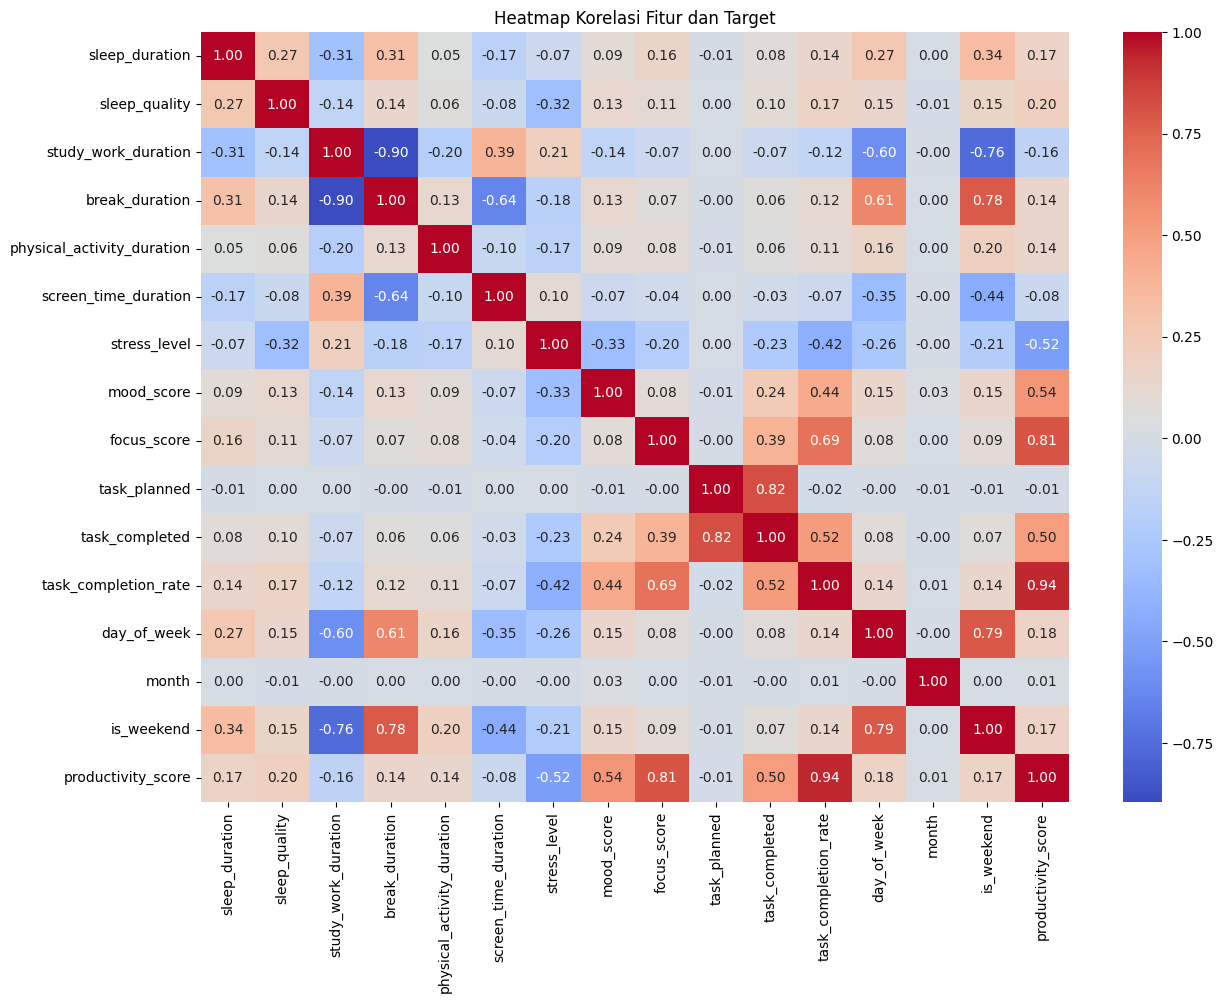

In [ ]:
plt.figure(figsize=(14, 10))
sns.heatmap(df[raw_features + [target_col]].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap Korelasi Fitur dan Target")
plt.show()

###**3.3 Time Series Decomposition**

Analisis dekomposisi dilakukan untuk memisahkan:
- tren,
- pola musiman,
- dan residual/noise

dari data produktivitas pengguna.

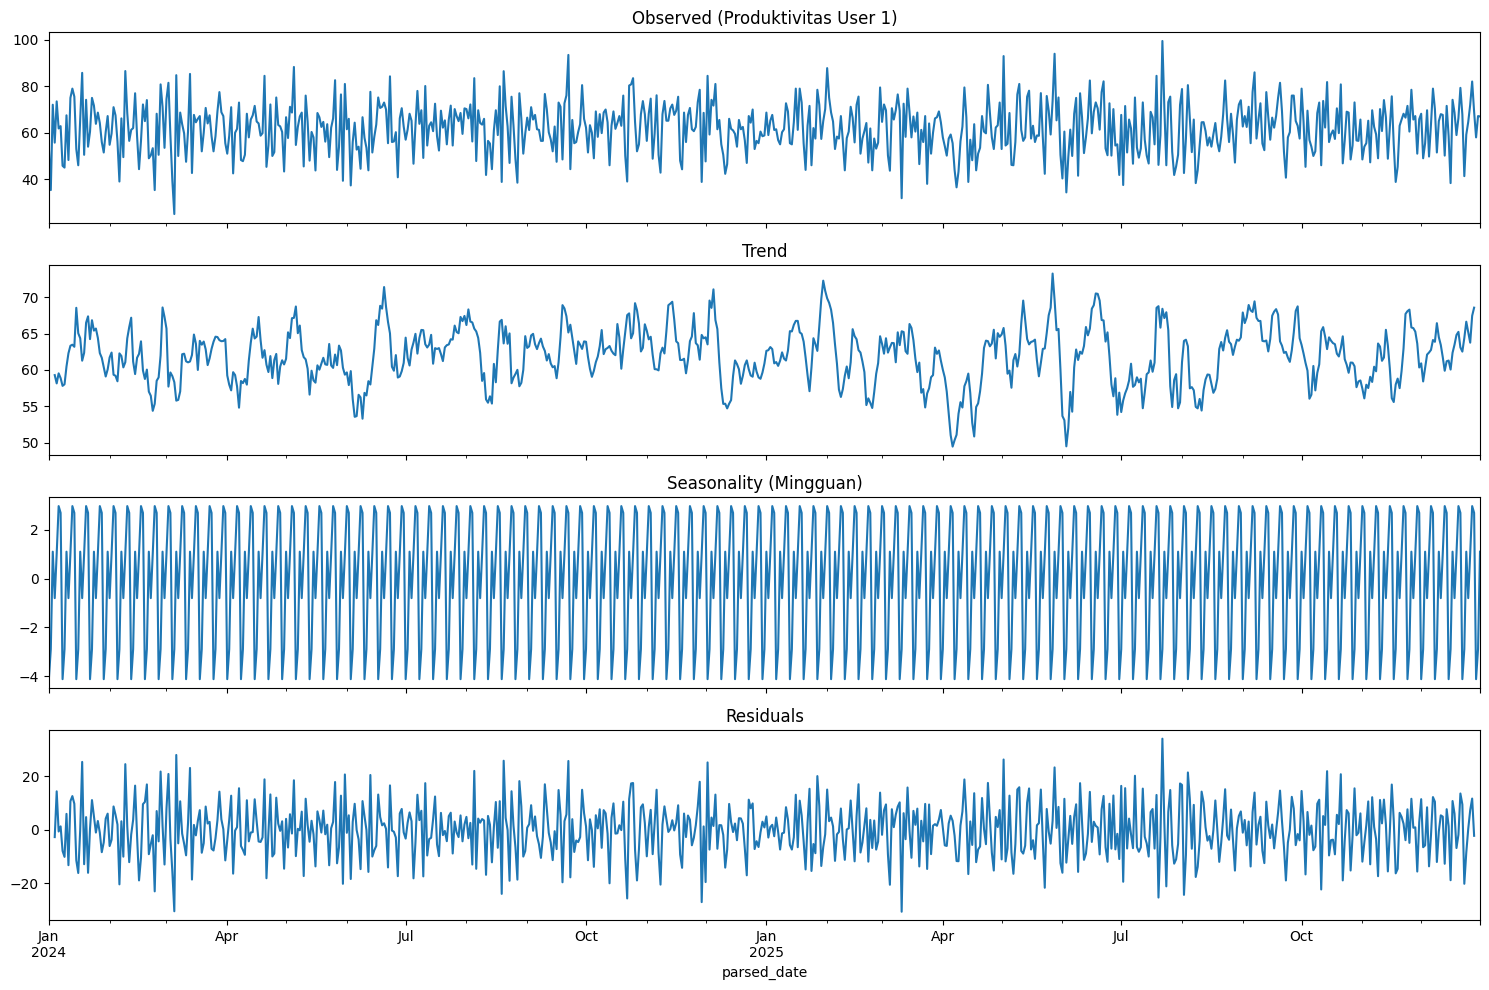

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Dekomposisi deret waktu untuk user 1 secara berurutan waktu
df_u1 = df[df['user_id'] == 1].copy()
df_u1['parsed_date'] = pd.to_datetime(df_u1['date'], format='%m/%d/%Y')
df_u1 = df_u1.sort_values(by='parsed_date').set_index('parsed_date')

decomposition = seasonal_decompose(df_u1['productivity_score'], model='additive', period=7)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(15, 10), sharex=True)
decomposition.observed.plot(ax=ax1, title='Observed (Produktivitas User 1)')
decomposition.trend.plot(ax=ax2, title='Trend')
decomposition.seasonal.plot(ax=ax3, title='Seasonality (Mingguan)')
decomposition.resid.plot(ax=ax4, title='Residuals')
plt.tight_layout()
plt.show()

##**3.4 Analisis Window Size Menggunakan ACF & PACF**

untuk menentukan panjang window sequence yang optimal pada model LSTM.

disini digunakan window size 7 hari karena sesuai dengan pola aktivitas mingguan pengguna.

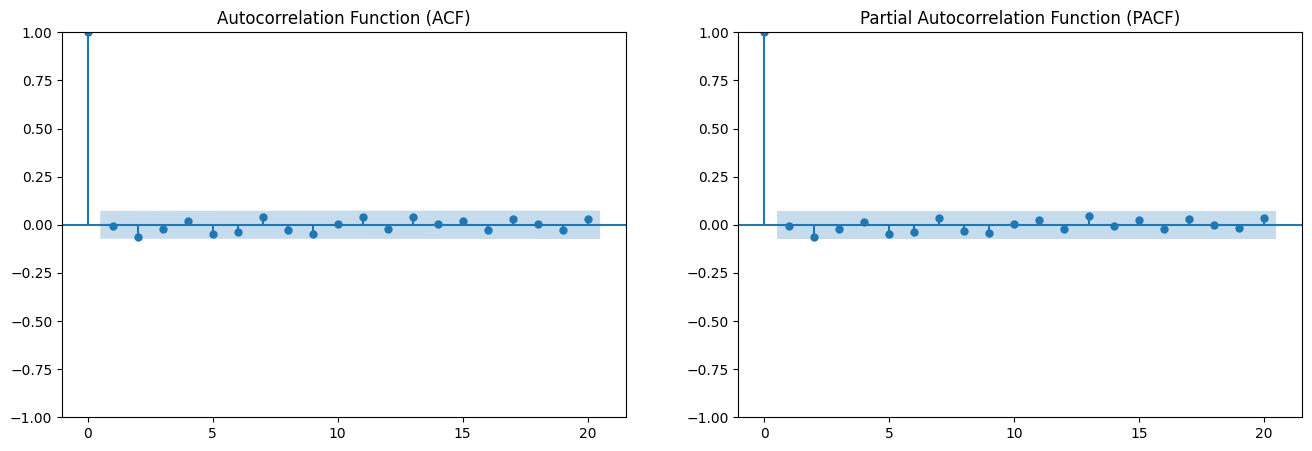

Hasil Analisis Data ACF/PACF
* Lag Awal: Nilai autokorelasi lag 1 (-0.005) berada DI DALAM batas signifikansi (±0.072). Data cenderung acak/stasioner di awal.
* Siklus Mingguan: Tidak ada korelasi kuat pada lag 7 (0.039 berada di dalam batas ±0.072).
  Kesimpulan: Pola siklus mingguan tidak terlihat dominan secara statistik pada data spesifik pengguna ini.
  Rekomendasi: Window size = 7 hari tetap bisa digunakan berdasarkan domain knowledge, namun tidak didukung korelasi kuat pada data.


In [ ]:
#plot
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(df_u1['productivity_score'], lags=20, ax=ax[0], title='Autocorrelation Function (ACF)')
plot_pacf(df_u1['productivity_score'], lags=20, ax=ax[1], title='Partial Autocorrelation Function (PACF)')
plt.show()

print("Hasil Analisis Data ACF/PACF")

#menghitung nilai ACF/PACF dan batas signifikansinya (Confidence Interval 95%)
n_obs = len(df_u1['productivity_score'])
conf_level = 1.96 / np.sqrt(n_obs)  #batas area biru (pendekatan standar)

#ambil nilai ACF dan PACF untuk lag 1 sampai 20 (lag 0 selalu = 1)
acf_values = acf(df_u1['productivity_score'], nlags=20)[1:]
pacf_values = pacf(df_u1['productivity_score'], nlags=20)[1:]

#cek lag 1 (lag awal) dan lag 7 (siklus mingguan)
lag_1_acf = acf_values[0]
lag_7_acf = acf_values[6]  # indeks 6 adalah lag 7

#pengecekan Lag Awal (Lag 1)
if abs(lag_1_acf) < conf_level:
    print(f"* Lag Awal: Nilai autokorelasi lag 1 ({lag_1_acf:.3f}) berada DI DALAM batas signifikansi (±{conf_level:.3f}). Data cenderung acak/stasioner di awal.")
else:
    print(f"* Lag Awal: Nilai autokorelasi lag 1 ({lag_1_acf:.3f}) berada DI LUAR batas signifikansi (±{conf_level:.3f}). Ada tren atau dependensi jangka pendek.")

#pengecekan Pola Mingguan (Lag 7)
if abs(lag_7_acf) > conf_level:
    print(f"* Siklus Mingguan: Terdeteksi korelasi signifikan pada lag 7 ({lag_7_acf:.3f}).")
    print("  Kesimpulan: Hipotesis pola perilaku mingguan (hari kerja vs akhir pekan) TERBUKTI secara statistik pada data ini.")
    print("  Rekomendasi: Sangat disarankan menggunakan window size = 7 hari.")
else:
    print(f"* Siklus Mingguan: Tidak ada korelasi kuat pada lag 7 ({lag_7_acf:.3f} berada di dalam batas ±{conf_level:.3f}).")
    print("  Kesimpulan: Pola siklus mingguan tidak terlihat dominan secara statistik pada data spesifik pengguna ini.")
    print("  Rekomendasi: Window size = 7 hari tetap bisa digunakan berdasarkan domain knowledge, namun tidak didukung korelasi kuat pada data.")

##**4. Feature Engineering dan Pelabelan Data**
untuk meningkatkan kualitas fitur agar model dapat memahami kondisi pengguna dengan lebih baik.

###**4.1 Pembuatan Fitur Cumulative Fatigue**

Fitur `cumulative_fatigue` dibuat untuk merepresentasikan akumulasi tingkat kelelahan pengguna berdasarkan:
- tingkat stres,
- durasi kerja,
- kualitas tidur,
- dan durasi tidur.

In [ ]:
#fatigue harian dihitung per baris data
df['fatigue_index'] = (df['stress_level'] / 10.0) * 0.4 + (df['study_work_duration'] / (df['sleep_duration'] + 1e-5)) * 0.3 + (1.0 - df['sleep_quality'] / 10.0) * 0.3

#akumulasi kelelahan rolling sum selama 3 hari dihitung secara terpisah per user_id
df['cumulative_fatigue'] = df.groupby('user_id')['fatigue_index'].transform(lambda x: x.rolling(window=3, min_periods=1).sum())
print("Fitur cumulative_fatigue berhasil dibuat.")

Fitur cumulative_fatigue berhasil dibuat.


###**4.2 Pelabelan Kondisi Pengguna**

Data diklasifikasikan menjadi tiga kategori:

- 🔴 **At Risk** → Produktivitas rendah
- 🟡 **Steady** → Produktivitas stabil
- 🟢 **Thriving** → Produktivitas tinggi

Pelabelan dilakukan berdasarkan nilai productivity score.

In [ ]:
df['target_reg'] = df['productivity_score']

def get_class_label(val):
    if pd.isna(val):
        return np.nan
    if val < 55.0:
        return 0  # At Risk
    elif val <= 67.0:
        return 1  # Steady
    else:
        return 2  # Thriving

df['target_clf'] = df['target_reg'].apply(get_class_label)
df = df.dropna(subset=['target_reg', 'target_clf']).reset_index(drop=True)
print("Dataset terlabel, ukuran:", df.shape)

Dataset terlabel, ukuran: (73100, 22)


###**4.3 Visualisasi Distribusi Data dan Label**

Visualisasi digunakan untuk:
- melihat distribusi fitur baru,
- serta memastikan distribusi label tetap seimbang.

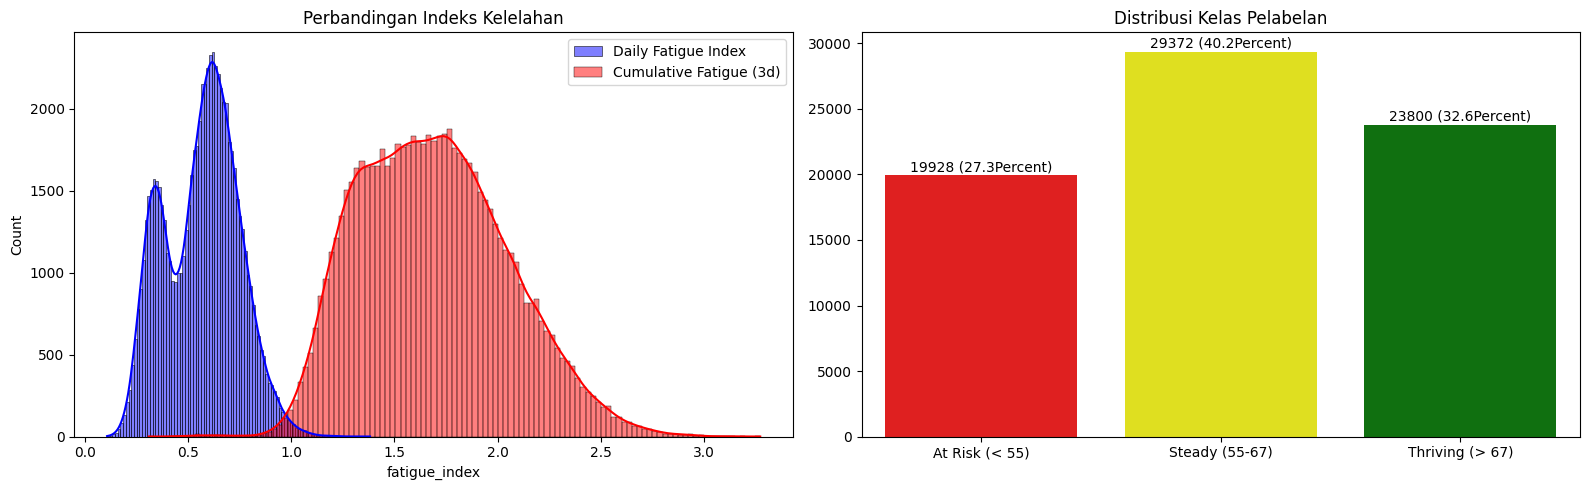

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

#visualisasi fitur baru sebelum vs sesudah rolling sum
sns.histplot(data=df, x='fatigue_index', color='blue', alpha=0.5, label='Daily Fatigue Index', kde=True, ax=ax[0])
sns.histplot(data=df, x='cumulative_fatigue', color='red', alpha=0.5, label='Cumulative Fatigue (3d)', kde=True, ax=ax[0])
ax[0].set_title('Perbandingan Indeks Kelelahan')
ax[0].legend()

#visualisasi distribusi kelas target klasifikasi untuk mendeteksi ketidakseimbangan kelas
label_counts = df['target_clf'].value_counts().sort_index()
labels = ['At Risk (< 55)', 'Steady (55-67)', 'Thriving (> 67)']
sns.barplot(x=labels, y=label_counts.values, hue=labels, palette=['red', 'yellow', 'green'], ax=ax[1], legend=False)
ax[1].set_title('Distribusi Kelas Pelabelan')
for i, count in enumerate(label_counts.values):
    ax[1].text(i, count + 300, f"{count} ({count/len(df)*100:.1f}Percent)", ha='center')

plt.tight_layout()
plt.show()

##**5. Preprocessing Data (Anti Data Leakage)**

Tahap preprocessing dilakukan dengan aturan ketat agar tidak terjadi kebocoran data (*data leakage*).


###**5.1 Pembagian Data Secara Kronologis**

Dataset dibagi menjadi:
- Train Set (70%)
- Validation Set (15%)
- Test Set (15%)

Pembagian dilakukan berdasarkan urutan waktu setiap pengguna.

In [ ]:
train_dfs, val_dfs, test_dfs = [], [], []
for user_id, group in df.groupby('user_id'):
    n = len(group)
    n_train = int(n * 0.70)
    n_val = int(n * 0.15)
    train_dfs.append(group.iloc[:n_train])
    val_dfs.append(group.iloc[n_train:n_train+n_val])
    test_dfs.append(group.iloc[n_train+n_val:])

train_df = pd.concat(train_dfs).reset_index(drop=True)
val_df = pd.concat(val_dfs).reset_index(drop=True)
test_df = pd.concat(test_dfs).reset_index(drop=True)

print(f"Ukuran subset: Train={len(train_df)}, Val={len(val_df)}, Test={len(test_df)}")

Ukuran subset: Train=51100, Val=10900, Test=11100


###**5.2 Normalisasi Fitur**

Normalisasi menggunakan `MinMaxScaler` agar seluruh fitur memiliki rentang nilai yang konsisten.

Scaler hanya di-*fit* pada data train untuk mencegah data leakage.

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import pickle

feature_cols = [
    'sleep_duration', 'sleep_quality', 'study_work_duration', 'break_duration',
    'physical_activity_duration', 'screen_time_duration', 'stress_level', 'mood_score',
    'focus_score', 'task_planned', 'task_completed', 'task_completion_rate',
    'day_of_week', 'month', 'is_weekend', 'cumulative_fatigue'
]

#normalisasi fitur
feature_scaler = MinMaxScaler()
feature_scaler.fit(train_df[feature_cols])

#normalisasi target regresi
target_scaler = MinMaxScaler()
target_scaler.fit(train_df[['target_reg']])

#transformasikan
train_features_scaled = feature_scaler.transform(train_df[feature_cols])
val_features_scaled = feature_scaler.transform(val_df[feature_cols])
test_features_scaled = feature_scaler.transform(test_df[feature_cols])

#ekspor scaler
with open('feature_scaler.pkl', 'wb') as f:
    pickle.dump(feature_scaler, f)
with open('target_scaler.pkl', 'wb') as f:
    pickle.dump(target_scaler, f)

print("Penskalaan selesai. Scaler tersimpan.")

Penskalaan selesai. Scaler tersimpan.


###**5.3 Pembuatan Sequence 3D untuk LSTM**

Data diubah menjadi bentuk tensor 3D:

```text
[samples, time_steps, features]
```

menggunakan metode sliding window selama 7 hari.

In [ ]:
def generate_sequences_for_split(df_split, feat_scaler, targ_scaler, window_size=7):
    X_list, y_reg_list, y_clf_list = [], [], []
    for user_id, group in df_split.groupby('user_id'):
        feats = feat_scaler.transform(group[feature_cols])
        targ_reg = targ_scaler.transform(group[['target_reg']]).flatten()
        targ_clf = tf.keras.utils.to_categorical(group['target_clf'].values, num_classes=3)

        #target diselaraskan pada hari ke-7 (i + window_size - 1)
        for i in range(len(group) - window_size + 1):
            X_list.append(feats[i : i + window_size])
            y_reg_list.append(targ_reg[i + window_size - 1])
            y_clf_list.append(targ_clf[i + window_size - 1])

    return np.array(X_list), np.array(y_reg_list), np.array(y_clf_list)

X_train, y_train_reg, y_train_clf = generate_sequences_for_split(train_df, feature_scaler, target_scaler)
X_val, y_val_reg, y_val_clf = generate_sequences_for_split(val_df, feature_scaler, target_scaler)
X_test, y_test_reg, y_test_clf = generate_sequences_for_split(test_df, feature_scaler, target_scaler)

#cast ke float32
X_train, y_train_reg, y_train_clf = X_train.astype(np.float32), y_train_reg.astype(np.float32), y_train_clf.astype(np.float32)
X_val, y_val_reg, y_val_clf = X_val.astype(np.float32), y_val_reg.astype(np.float32), y_val_clf.astype(np.float32)
X_test, y_test_reg, y_test_clf = X_test.astype(np.float32), y_test_reg.astype(np.float32), y_test_clf.astype(np.float32)

print("Dimensi akhir tensor 3D:")
print("Train X:", X_train.shape, "y_reg:", y_train_reg.shape, "y_clf:", y_train_clf.shape)
print("Val X:", X_val.shape, "y_reg:", y_val_reg.shape, "y_clf:", y_val_clf.shape)
print("Test X:", X_test.shape, "y_reg:", y_test_reg.shape, "y_clf:", y_test_clf.shape)

Dimensi akhir tensor 3D:
Train X: (50500, 7, 16) y_reg: (50500,) y_clf: (50500, 3)
Val X: (10300, 7, 16) y_reg: (10300,) y_clf: (10300, 3)
Test X: (10500, 7, 16) y_reg: (10500,) y_clf: (10500, 3)


##**6. Perancangan Model Multi-Output LSTM**

Tahap pembangunan arsitektur deep learning.

Model dirancang untuk menghasilkan:
- output regresi,
- dan output klasifikasi

dalam satu model secara bersamaan.

##**6.1 Konfigurasi Model**

Menentukan:
- struktur model,
- jumlah neuron,
- activation function,
- dan parameter pelatihan.

###**6.2 Arsitektur Utama Model**

Model menggunakan:
- LSTM Layer
- Attention Layer
- Dense Layer
- Multi-Output Prediction

###**6.3 Integrasi Custom Attention Layer**

Attention Layer membantu model fokus pada informasi waktu yang paling penting dalam sequence pengguna.


In [ ]:
# Layer Attention Kustom dengan dukungan serialisasi penuh
@tf.keras.utils.register_keras_serializable(package="Custom")
class CustomAttention(layers.Layer):
    def __init__(self, **kwargs):
        super(CustomAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(
            name="att_weight",
            shape=(input_shape[-1], 1),
            initializer="glorot_uniform",
            trainable=True
        )
        self.b = self.add_weight(
            name="att_bias",
            shape=(input_shape[1], 1),
            initializer="zeros",
            trainable=True
        )
        super(CustomAttention, self).build(input_shape)

    def call(self, inputs):
        #inputs shape: (batch_size, time_steps, features)
        e = tf.tensordot(inputs, self.W, axes=[-1, 0]) + self.b
        alpha = tf.nn.softmax(e, axis=1) # (batch_size, time_steps, 1)
        context = inputs * alpha
        context = tf.reduce_sum(context, axis=1) # (batch_size, features)
        return context

    def get_config(self):
        return super(CustomAttention, self).get_config()

#pembangunan model melalui Functional API
inputs = layers.Input(shape=(7, 16), name="input_layer")
lstm_out = layers.LSTM(64, return_sequences=True, name="lstm_layer")(inputs)
attention_out = CustomAttention(name="attention_layer")(lstm_out)
dense_shared = layers.Dense(32, activation="relu", name="dense_shared")(attention_out)

#output 1: Regresi Skor Produktivitas (Sigmoid karena target [0,1])
out_reg = layers.Dense(1, activation="sigmoid", name="out_regression")(dense_shared)

#output 2: Klasifikasi 3 Kategori (Softmax)
out_clf = layers.Dense(3, activation="softmax", name="out_classification")(dense_shared)

model = tf.keras.Model(inputs=inputs, outputs=[out_reg, out_clf], name="multi_output_lstm")
model.summary()

Model: "multi_output_lstm"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 7, 16)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_layer (LSTM)   │ (None, 7, 64)     │     20,736 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_layer     │ (None, 64)        │         71 │ lstm_layer[0][0]  │
│ (CustomAttention)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_shared        │ (None, 32)        │      2,080 │ attention_layer[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ out_regression      │ (None, 1)         │         33 │ dense_shared[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ out_classification  │ (None, 3)         │         99 │ dense_shared[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,019 (89.92 KB)

 Trainable params: 23,019 (89.92 KB)

 Non-trainable params: 0 (0.00 B)

##**7. Pelatihan Model dan Monitoring**

Tahap training model menggunakan custom training loop berbasis `tf.GradientTape`.

### **7.1 Input Pipeline dengan tf.data.Dataset**

Pipeline data digunakan agar proses training lebih cepat dan efisien.

###**7.2 TensorBoard dan Monitoring**

TensorBoard digunakan untuk memantau:
- loss,
- MAE,
- dan akurasi model

selama proses pelatihan.

###**7.3 Custom Training Loop**

Training dilakukan secara manual menggunakan:
- GradientTape,
- custom loss,
- dan custom callback.


In [ ]:
#pipeline tf.data.Dataset
train_ds = tf.data.Dataset.from_tensor_slices((X_train, {"out_regression": y_train_reg, "out_classification": y_train_clf}))
train_ds = train_ds.shuffle(10000).batch(128).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, {"out_regression": y_val_reg, "out_classification": y_val_clf}))
val_ds = val_ds.batch(128).prefetch(tf.data.AUTOTUNE)

#define optimizer dan metrik
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
alpha_loss = tf.constant(1.0, dtype=tf.float32)
beta_loss = tf.constant(3.0, dtype=tf.float32)

train_mae = tf.keras.metrics.MeanAbsoluteError()
train_acc = tf.keras.metrics.CategoricalAccuracy()
val_mae = tf.keras.metrics.MeanAbsoluteError()
val_acc = tf.keras.metrics.CategoricalAccuracy()

@tf.function
def train_step(x, y_reg, y_clf):
    with tf.GradientTape() as tape:
        y_pred_reg, y_pred_clf = model(x, training=True)
        y_pred_reg_sq = tf.squeeze(y_pred_reg, axis=-1)
        loss_reg = tf.reduce_mean(tf.square(y_reg - y_pred_reg_sq))
        loss_clf = tf.reduce_mean(tf.keras.losses.categorical_crossentropy(y_clf, y_pred_clf))
        loss_total = alpha_loss * loss_reg + beta_loss * loss_clf

    gradients = tape.gradient(loss_total, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    train_mae.update_state(y_reg, y_pred_reg_sq)
    train_acc.update_state(y_clf, y_pred_clf)
    return loss_total, loss_reg, loss_clf

@tf.function
def val_step(x, y_reg, y_clf):
    y_pred_reg, y_pred_clf = model(x, training=False)
    y_pred_reg_sq = tf.squeeze(y_pred_reg, axis=-1)
    loss_reg = tf.reduce_mean(tf.square(y_reg - y_pred_reg_sq))
    loss_clf = tf.reduce_mean(tf.keras.losses.categorical_crossentropy(y_clf, y_pred_clf))
    loss_total = alpha_loss * loss_reg + beta_loss * loss_clf

    val_mae.update_state(y_reg, y_pred_reg_sq)
    val_acc.update_state(y_clf, y_pred_clf)
    return loss_total, loss_reg, loss_clf

#tensorboard writer
current_time = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
train_writer = tf.summary.create_file_writer(f'logs/gradient_tape/{current_time}/train')
val_writer = tf.summary.create_file_writer(f'logs/gradient_tape/{current_time}/val')

#custom training loop
epochs = 50
patience = 5  #early stopping
wait = 0
best_val_loss = float('inf')
history_metrics = {'train_loss': [], 'train_mae': [], 'train_acc': [], 'val_loss': [], 'val_mae': [], 'val_acc': []}

for epoch in range(epochs):
    train_mae.reset_state()
    train_acc.reset_state()
    val_mae.reset_state()
    val_acc.reset_state()

    total_train_loss = 0.0
    train_batches = 0
    for x_batch, y_batch in train_ds:
        loss_total, _, _ = train_step(x_batch, y_batch['out_regression'], y_batch['out_classification'])
        total_train_loss += loss_total.numpy()
        train_batches += 1
    avg_train_loss = total_train_loss / train_batches

    total_val_loss = 0.0
    val_batches = 0
    for x_batch_val, y_batch_val in val_ds:
        val_loss_total, _, _ = val_step(x_batch_val, y_batch_val['out_regression'], y_batch_val['out_classification'])
        total_val_loss += val_loss_total.numpy()
        val_batches += 1
    avg_val_loss = total_val_loss / val_batches

    #simpan history metrik
    history_metrics['train_loss'].append(avg_train_loss)
    history_metrics['train_mae'].append(train_mae.result().numpy())
    history_metrics['train_acc'].append(train_acc.result().numpy())
    history_metrics['val_loss'].append(avg_val_loss)
    history_metrics['val_mae'].append(val_mae.result().numpy())
    history_metrics['val_acc'].append(val_acc.result().numpy())

    #log ke tensorBoard
    with train_writer.as_default():
        tf.summary.scalar('loss', avg_train_loss, step=epoch)
        tf.summary.scalar('mae', train_mae.result(), step=epoch)
        tf.summary.scalar('accuracy', train_acc.result(), step=epoch)
    with val_writer.as_default():
        tf.summary.scalar('loss', avg_val_loss, step=epoch)
        tf.summary.scalar('mae', val_mae.result(), step=epoch)
        tf.summary.scalar('accuracy', val_acc.result(), step=epoch)

    print(f"Epoch {epoch+1:02d}/{epochs} - loss: {avg_train_loss:.4f} - mae: {train_mae.result().numpy():.4f} - acc: {train_acc.result().numpy():.4f} | val_loss: {avg_val_loss:.4f} - val_mae: {val_mae.result().numpy():.4f} - val_acc: {val_acc.result().numpy():.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        wait = 0  # reset counter
        model.save('best_model.keras')
        print(f"   [Callback] Model terbaik disimpan dengan val_loss: {best_val_loss:.4f}")
    else:
        wait += 1
        print(f"   [Early Stopping] Tidak ada improvement. Patience: {wait}/{patience}")
        if wait >= patience:
            print(f"\n   [Early Stopping] Training dihentikan di epoch {epoch+1}. Val_loss tidak membaik selama {patience} epoch berturut-turut.")
            break

print(f"\nTraining selesai. Best val_loss: {best_val_loss:.4f}")

Epoch 01/50 - loss: 2.3115 - mae: 0.0724 - acc: 0.6521 | val_loss: 0.7950 - val_mae: 0.0284 - val_acc: 0.9587
   [Callback] Model terbaik disimpan dengan val_loss: 0.7950
Epoch 02/50 - loss: 0.5079 - mae: 0.0254 - acc: 0.9570 | val_loss: 0.3454 - val_mae: 0.0227 - val_acc: 0.9778
   [Callback] Model terbaik disimpan dengan val_loss: 0.3454
Epoch 03/50 - loss: 0.2944 - mae: 0.0207 - acc: 0.9718 | val_loss: 0.2662 - val_mae: 0.0256 - val_acc: 0.9736
   [Callback] Model terbaik disimpan dengan val_loss: 0.2662
Epoch 04/50 - loss: 0.2356 - mae: 0.0175 - acc: 0.9742 | val_loss: 0.2018 - val_mae: 0.0149 - val_acc: 0.9836
   [Callback] Model terbaik disimpan dengan val_loss: 0.2018
Epoch 05/50 - loss: 0.1995 - mae: 0.0148 - acc: 0.9773 | val_loss: 0.2590 - val_mae: 0.0173 - val_acc: 0.9568
   [Early Stopping] Tidak ada improvement. Patience: 1/5
Epoch 06/50 - loss: 0.1780 - mae: 0.0140 - acc: 0.9801 | val_loss: 0.1559 - val_mae: 0.0146 - val_acc: 0.9857
   [Callback] Model terbaik disimpan de

##**8. Evaluasi Kinerja Model**

Tahap evaluasi dilakukan menggunakan data test yang belum pernah dilihat model sebelumnya.

###**8.1 Evaluasi Akurasi dan MAE**

Target performa model:
- Accuracy ≥ 85%
- MAE ≤ 0.02


In [ ]:
#memuat kembali model terbaik hasil latihan
best_model = tf.keras.models.load_model('best_model.keras', custom_objects={'CustomAttention': CustomAttention})

#prediksi pada data test yang benar-benar baru
test_pred_reg, test_pred_clf = best_model.predict(X_test)
test_pred_reg_sq = test_pred_reg.squeeze()

#evaluasi metrik targets
test_mae_metric = tf.keras.metrics.MeanAbsoluteError()
test_mae_metric.update_state(y_test_reg, test_pred_reg_sq)
test_mae_val = test_mae_metric.result().numpy()

test_acc_metric = tf.keras.metrics.CategoricalAccuracy()
test_acc_metric.update_state(y_test_clf, test_pred_clf)
test_acc_val = test_acc_metric.result().numpy()


print("HASIL PENGUJIAN AKHIR MODEL DATA TEST")
print(f"Akurasi Klasifikasi : {test_acc_val * 100:.2f}% (Target: >= 85%)")
print(f"Regression MAE      : {test_mae_val:.4f} (Target: <= 0.02)")

if test_acc_val >= 0.85 and test_mae_val <= 0.02:
    print("STATUS: TARGET KINERJA BERHASIL DIPENUHI!")
else:
    print("STATUS: TARGET KINERJA GAGAL DIPENUHI. SILAKAN SESUAIKAN KEMBALI HYPERPARAMETER.")

329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
HASIL PENGUJIAN AKHIR MODEL DATA TEST
Akurasi Klasifikasi : 99.29% (Target: >= 85%)
Regression MAE      : 0.0070 (Target: <= 0.02)
STATUS: TARGET KINERJA BERHASIL DIPENUHI!


###**8.2 Visualisasi Hasil Evaluasi**

Visualisasi meliputi:
- kurva loss,
- kurva akurasi,
- dan confusion matrix.

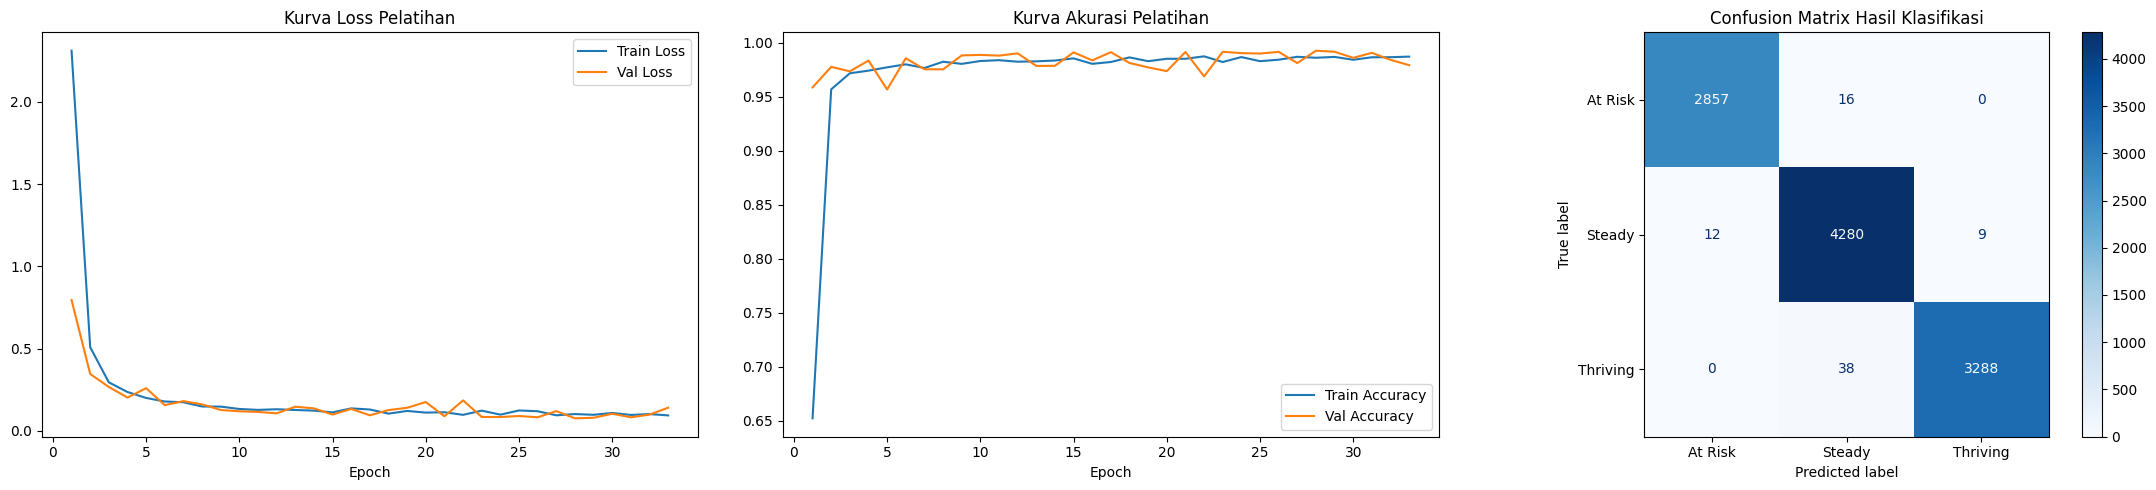

In [ ]:
#visualisasi kurva pelatihan dan confusion matrix
epochs_range = range(1, len(history_metrics['train_loss']) + 1)
fig, ax = plt.subplots(1, 3, figsize=(22, 5))

#kurva loss
ax[0].plot(epochs_range, history_metrics['train_loss'], label='Train Loss')
ax[0].plot(epochs_range, history_metrics['val_loss'], label='Val Loss')
ax[0].set_title('Kurva Loss Pelatihan')
ax[0].set_xlabel('Epoch')
ax[0].legend()

#kurva akurasi
ax[1].plot(epochs_range, history_metrics['train_acc'], label='Train Accuracy')
ax[1].plot(epochs_range, history_metrics['val_acc'], label='Val Accuracy')
ax[1].set_title('Kurva Akurasi Pelatihan')
ax[1].set_xlabel('Epoch')
ax[1].legend()

#confusion matrix
y_test_true_classes = np.argmax(y_test_clf, axis=1)
y_test_pred_classes = np.argmax(test_pred_clf, axis=1)
cm = confusion_matrix(y_test_true_classes, y_test_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['At Risk', 'Steady', 'Thriving'])
disp.plot(cmap='Blues', ax=ax[2])
ax[2].set_title('Confusion Matrix Hasil Klasifikasi')

plt.tight_layout()
plt.show()

##**9. Deployment dan Simulasi Produksi**

Tahap akhir untuk menyimpan model dan melakukan simulasi prediksi pada data baru.

###**9.1 Export Model**

Model terbaik disimpan dalam format `.keras` agar dapat digunakan kembali pada aplikasi produksi.

In [ ]:
#ekspor model secara penuh ke dalam format .keras
best_model.save('final_lstm_multioutput.keras')
print("Model akhir berhasil disimpan ke 'final_lstm_multioutput.keras'")

Model akhir berhasil disimpan ke 'final_lstm_multioutput.keras'


###**9.2 Simulasi Prediksi End-to-End**

Simulasi dilakukan menggunakan data aktivitas pengguna selama 7 hari untuk memprediksi:
- skor produktivitas,
- kategori kondisi pengguna,
- dan rekomendasi kondisi pengguna.

In [ ]:
def simulate_inference(raw_7day_logs, feat_scaler_path='feature_scaler.pkl', target_scaler_path='target_scaler.pkl', model_path='final_lstm_multioutput.keras'):
    import pickle
    with open(feat_scaler_path, 'rb') as f:
        fs = pickle.load(f)
    with open(target_scaler_path, 'rb') as f:
        ts = pickle.load(f)
    model_inf = tf.keras.models.load_model(model_path, custom_objects={'CustomAttention': CustomAttention})

    df_raw = pd.DataFrame(raw_7day_logs)

    #rekayasa fitur
    df_raw['fatigue_index'] = (df_raw['stress_level'] / 10.0) * 0.4 + (df_raw['study_work_duration'] / (df_raw['sleep_duration'] + 1e-5)) * 0.3 + (1.0 - df_raw['sleep_quality'] / 10.0) * 0.3
    df_raw['cumulative_fatigue'] = df_raw['fatigue_index'].rolling(window=3, min_periods=1).sum()

    #scaling
    feats_scaled = fs.transform(df_raw[feature_cols])
    feats_scaled_3d = np.expand_dims(feats_scaled, axis=0) # shape (1, 7, 16)

    #prediksi
    pred_reg, pred_clf = model_inf.predict(feats_scaled_3d)

    #kembalikan ke nilai asli
    reg_score_original = ts.inverse_transform(pred_reg)[0][0]
    predicted_class_idx = np.argmax(pred_clf[0])
    classes = ['At Risk', 'Steady', 'Thriving']
    predicted_class_name = classes[predicted_class_idx]

    return reg_score_original, predicted_class_name, pred_clf[0]

# 1. Kondisi 1: PRIMA & SEHAT (Thriving)
logs_thriving = []
for i in range(7):
    logs_thriving.append({
        'sleep_duration': 8.0, 'sleep_quality': 9, 'study_work_duration': 6.0,
        'break_duration': 1.0, 'physical_activity_duration': 45, 'screen_time_duration': 2.0,
        'stress_level': 2, 'mood_score': 9, 'focus_score': 9,
        'task_planned': 5, 'task_completed': 5, 'task_completion_rate': 1.0,
        'day_of_week': i % 7, 'month': 5, 'is_weekend': 1 if (i % 7 in [5, 6]) else 0
    })

# 2. Kondisi 2: STABIL & SEIMBANG (Steady)
logs_steady = []
for i in range(7):
    logs_steady.append({
        'sleep_duration': 6.0, 'sleep_quality': 5, 'study_work_duration': 8.0,
        'break_duration': 0.4, 'physical_activity_duration': 15, 'screen_time_duration': 4.5,
        'stress_level': 5, 'mood_score': 5, 'focus_score': 6,
        'task_planned': 6, 'task_completed': 4, 'task_completion_rate': 0.667,
        'day_of_week': i % 7, 'month': 5, 'is_weekend': 1 if (i % 7 in [5, 6]) else 0
    })

# 3. Kondisi 3: LELAH & BURNOUT (At Risk)
logs_at_risk = []
for i in range(7):
    logs_at_risk.append({
        'sleep_duration': 4.5, 'sleep_quality': 3, 'study_work_duration': 10.0,
        'break_duration': 0.167, 'physical_activity_duration': 0, 'screen_time_duration': 8.0,
        'stress_level': 9, 'mood_score': 2, 'focus_score': 3,
        'task_planned': 8, 'task_completed': 2, 'task_completion_rate': 0.25,
        'day_of_week': i % 7, 'month': 5, 'is_weekend': 1 if (i % 7 in [5, 6]) else 0
    })

scenarios = {
    "Kondisi 1: PRIMA & SEHAT (Thriving)": logs_thriving,
    "Kondisi 2: STABIL & SEIMBANG (Steady)": logs_steady,
    "Kondisi 3: LELAH & BURNOUT (At Risk)": logs_at_risk
}

print("SIMULASI INFERENSI BERBAGAI KONDISI\n")
for sc_name, sc_logs in scenarios.items():
    score, category, probs = simulate_inference(sc_logs)
    print(f"{sc_name}:")
    print(f"  -> Prediksi Skor Produktivitas: {score:.2f}")
    print(f"  -> Prediksi Kategori Kondisi  : {category}")
    print(f"  -> Probabilitas Kelas         : [At Risk: {probs[0]:.4f}, Steady: {probs[1]:.4f}, Thriving: {probs[2]:.4f}]")
    if category == 'Thriving':
        print("  -> Rekomendasi: Pertahankan pola kerja dan gaya hidup yang sangat baik ini!\n")
    elif category == 'Steady':
        print("  -> Rekomendasi: Anda dalam kondisi stabil. Jaga keseimbangan antara bekerja dan beristirahat.\n")
    else:
        print("  -> Rekomendasi: PERINGATAN! Tingkat kelelahan Anda kritis. Kurangi beban kerja dan tidur yang cukup!\n")

SIMULASI INFERENSI BERBAGAI KONDISI

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
Kondisi 1: PRIMA & SEHAT (Thriving):
  -> Prediksi Skor Produktivitas: 89.25
  -> Prediksi Kategori Kondisi  : Thriving
  -> Probabilitas Kelas         : [At Risk: 0.0000, Steady: 0.0000, Thriving: 1.0000]
  -> Rekomendasi: Pertahankan pola kerja dan gaya hidup yang sangat baik ini!

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
Kondisi 2: STABIL & SEIMBANG (Steady):
  -> Prediksi Skor Produktivitas: 61.41
  -> Prediksi Kategori Kondisi  : Steady
  -> Probabilitas Kelas         : [At Risk: 0.0000, Steady: 1.0000, Thriving: 0.0000]
  -> Rekomendasi: Anda dalam kondisi stabil. Jaga keseimbangan antara bekerja dan beristirahat.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
Kondisi 3: LELAH & BURNOUT (At Risk):
  -> Prediksi Skor Produktivitas: 31.86
  -> Prediksi Kategori Kondisi  : At Risk
  -> Probabilitas Kelas         : [At Risk: 1.0000, Steady: 0.0000, Thriving: 0.0000]
  -> Rekomendasi: PERINGATAN! Tingkat kelelahan Anda

In [55]:
#inference 5 sampel random dari test set
import random
indices = random.sample(range(len(X_test)), 5)

print("=== Inference 5 Sampel Random dari Data Test ===\n")
for idx in indices:
    sample = X_test[idx:idx+1]
    pred_reg, pred_clf = best_model.predict(sample, verbose=0)
    reg_score = target_scaler.inverse_transform(pred_reg)[0][0]

    if reg_score < 55.0:
        category = 'At Risk'
    elif reg_score <= 67.0:
        category = 'Steady'
    else:
        category = 'Thriving'

    true_reg = target_scaler.inverse_transform([[y_test_reg[idx]]])[0][0]
    true_clf = ['At Risk', 'Steady', 'Thriving'][np.argmax(y_test_clf[idx])]
    match = "OK" if category == true_clf else "!"

    print(f"Index {idx} {match}")
    print(f"  Ground Truth : {true_reg:.2f} ({true_clf})")
    print(f"  Prediksi     : {reg_score:.2f} ({category})")
    print(f"  Prob         : [At Risk: {pred_clf[0][0]:.4f}, Steady: {pred_clf[0][1]:.4f}, Thriving: {pred_clf[0][2]:.4f}]\n")

=== Inference 5 Sampel Random dari Data Test ===

Index 4694 OK
  Ground Truth : 55.50 (Steady)
  Prediksi     : 55.18 (Steady)
  Prob         : [At Risk: 0.0211, Steady: 0.9789, Thriving: 0.0000]

Index 7814 OK
  Ground Truth : 65.00 (Steady)
  Prediksi     : 64.32 (Steady)
  Prob         : [At Risk: 0.0000, Steady: 0.9999, Thriving: 0.0001]

Index 3706 OK
  Ground Truth : 77.00 (Thriving)
  Prediksi     : 76.54 (Thriving)
  Prob         : [At Risk: 0.0000, Steady: 0.0000, Thriving: 1.0000]

Index 1483 OK
  Ground Truth : 85.50 (Thriving)
  Prediksi     : 84.43 (Thriving)
  Prob         : [At Risk: 0.0000, Steady: 0.0000, Thriving: 1.0000]

Index 7697 OK
  Ground Truth : 51.50 (At Risk)
  Prediksi     : 50.87 (At Risk)
  Prob         : [At Risk: 1.0000, Steady: 0.0000, Thriving: 0.0000]

